# **K-Means Clustering Assignment By Rasha**

# KMeans Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/usr/local/lib/python3.10/dist-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Dog Horse KMeans Challenge

In [2]:
# Import Data
df_dh = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/dog_or_horse.csv")
# We picked variables that we need
X = df_dh[['height', 'weight']]
df_dh.head()

,height,weight,target,type
0,27.0,71.0,0.0,dog
1,27.0,92.0,0.0,dog
2,32.0,47.0,0.0,dog
3,30.0,90.0,0.0,dog
4,28.0,91.0,0.0,dog


In [3]:
# Scale Data
sc = StandardScaler()
# Fit & transform data.
X_sc = sc.fit_transform(X)

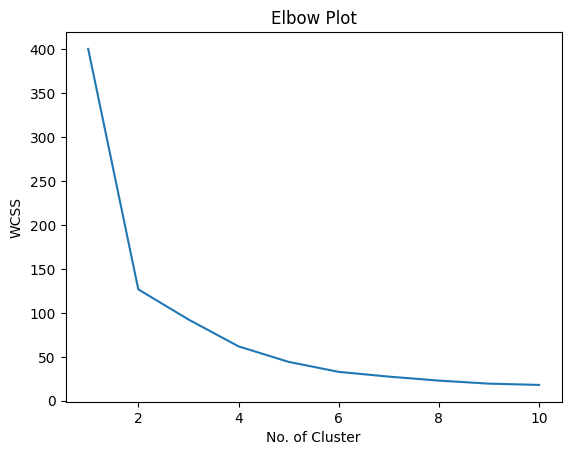

In [4]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=0)
    kmeans.fit(X_sc)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')

plt.show()

In [5]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X_sc)

In [6]:
print(y_kmeans)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0]


In [7]:
# Cluster centeriods
print (kmeans.cluster_centers_)

[[ 0.96628215  0.91732732]
 [-0.74395174 -0.70626086]]


In [8]:
# assign the y_kmeans to a new column in the dataset
df_dh['kmean_prid']= y_kmeans
df_dh

,height,weight,target,type,kmean_prid
0,27.0,71.0,0.0,dog,1
1,27.0,92.0,0.0,dog,1
2,32.0,47.0,0.0,dog,1
3,30.0,90.0,0.0,dog,1
4,28.0,91.0,0.0,dog,1
...,...,...,...,...,...
195,55.0,140.0,1.0,horse,0
196,82.0,179.0,1.0,horse,0
197,46.0,132.0,1.0,horse,0
198,56.0,89.0,1.0,horse,1


### Plot the clusters including the centroid for each of the clusters as defined by K-Means

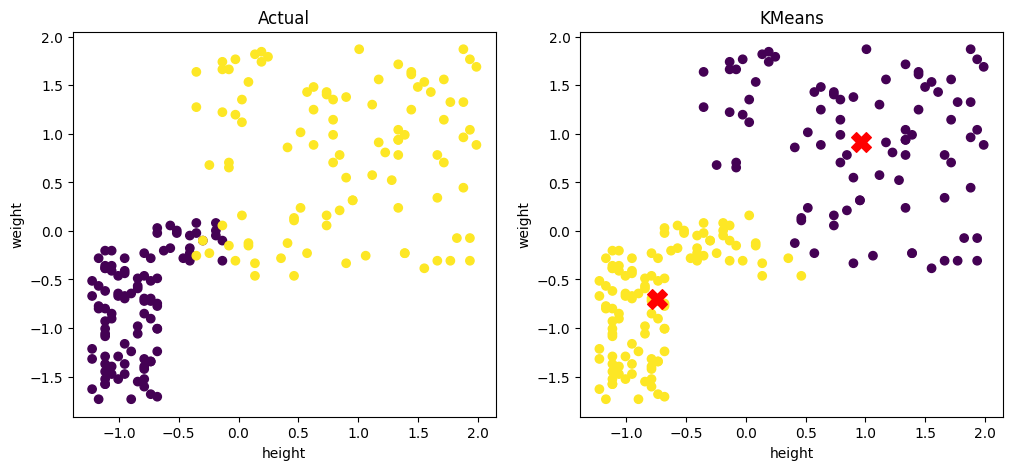

In [9]:
# Create a scatter plot of the actual results and the KMeans results
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_sc[:,0], X_sc[:,1], c=df_dh['target'])
plt.title('Actual')
plt.xlabel('height')
plt.ylabel('weight')

plt.subplot(1,2,2)
plt.scatter(X_sc[:,0], X_sc[:,1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, c='red', marker='X')
plt.title('KMeans')
plt.xlabel('height')
plt.ylabel('weight')

plt.show()

In [10]:
# replace dog with 1 and horse with 0 to help us caluclate the Accuracy Score
df_dh['type'] = df_dh['type'].map({'dog':1, 'horse':0})

In [11]:
# Calculate the number of correct predictions
(df_dh['type'] == df_dh['kmean_prid']).value_counts()

True     187
False     13
Name: count, dtype: int64

In [12]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_dh['type'], df_dh['kmean_prid'])*100

93.5

# Seattle Weather KMeans Challenge

In [13]:
df_sea = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/seattle_weather_1948-2017.csv")
X_sea = df_sea[['tmax', 'tmin']]
df_sea.head()

,ds,prcp,tmax,tmin,rain
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [14]:
# Scale Data
sc_sea = StandardScaler()
# Fit & transform data.
X_sea_sc = sc_sea.fit_transform(X_sea)

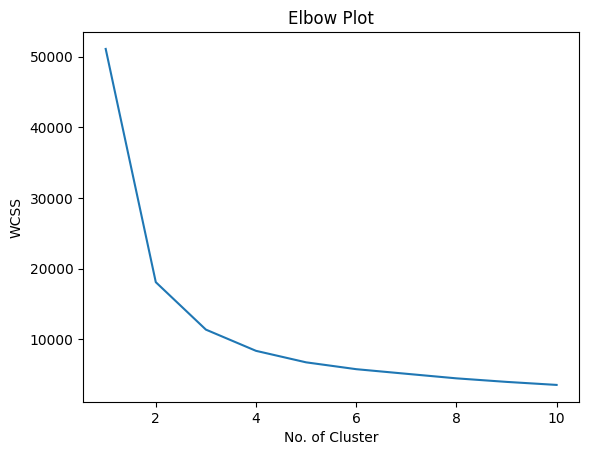

In [15]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=0)
    kmeans.fit(X_sea_sc)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')
plt.show()

# From the plot we can see that the optimal number of clusters in 4, but our target is 2 so we should pick 2.

In [16]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans_sea = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=0)
y_sea_kmeans = kmeans_sea.fit_predict(X_sea_sc)

In [17]:
print(y_sea_kmeans)

[1 1 1 ... 1 1 1]


In [18]:
# assign the y_kmeans to a new column
df_sea['kmean_sea_prid']= y_sea_kmeans
df_sea

,ds,prcp,tmax,tmin,rain,kmean_sea_prid
0,1948-01-01,0.47,51,42,True,1
1,1948-01-02,0.59,45,36,True,1
2,1948-01-03,0.42,45,35,True,1
3,1948-01-04,0.31,45,34,True,1
4,1948-01-05,0.17,45,32,True,1
...,...,...,...,...,...,...
25546,2017-12-10,0.00,49,34,False,1
25547,2017-12-11,0.00,49,29,False,1
25548,2017-12-12,0.00,46,32,False,1
25549,2017-12-13,0.00,48,34,False,1


In [19]:
# replace True with 1 and False with 0 to help us caluclate the Accuracy Score
df_sea['rain'] = df_sea['rain'].map({True:1, False:0})

In [20]:
# Calculate the number of correct predictions
(df_sea['rain'] == df_sea['kmean_sea_prid']).value_counts()

True     16266
False     9285
Name: count, dtype: int64

In [21]:
df_sea.dropna(subset = ['rain'], inplace=True)

In [22]:
df_sea['rain'].isna().sum()

0

### Plot the clusters including the centroid for each of the clusters as defined by K-Means

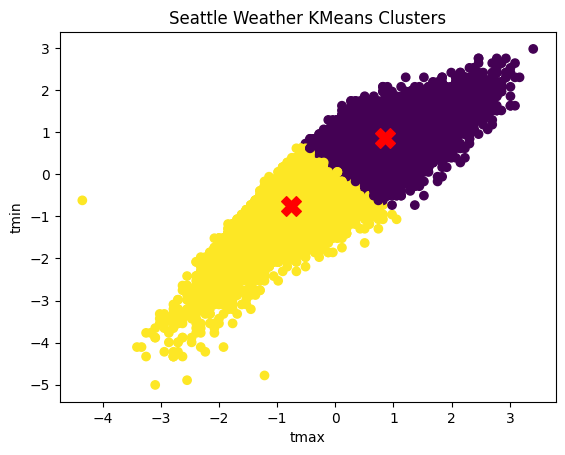

In [23]:
plt.scatter(X_sea_sc[:,0], X_sea_sc[:,1], c=y_sea_kmeans)
plt.scatter(kmeans_sea.cluster_centers_[:,0], kmeans_sea.cluster_centers_[:,1], s=200, c='red', marker='X')
plt.title('Seattle Weather KMeans Clusters')
plt.xlabel('tmax')
plt.ylabel('tmin')
plt.show()

In [24]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_sea['rain'], df_sea['kmean_sea_prid'])*100

63.66838891498357

# Random Blob KMeans Challenge

- You dont have true labels for this data so this is truly an unsupervised dataset
- The blobs are randomly generated every time you run the cell and their characteristics are:
    - 2000-4000 data points
    - 10-30 blobs created

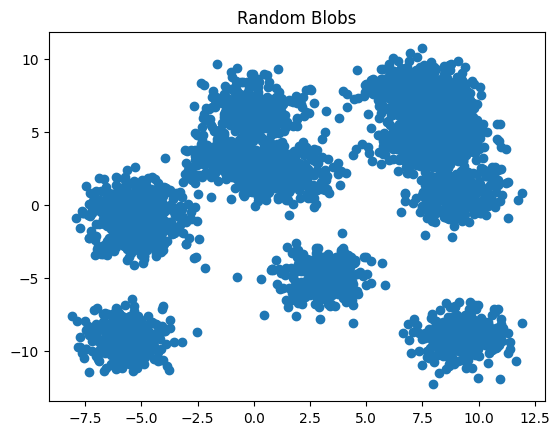

In [25]:
n_samples = random.randint(2000, 4000)
n_centers = random.randint(10, 30)
df_blob, blob_labels = make_blobs(n_samples=n_samples, n_features=2, centers=n_centers)

plt.scatter(df_blob[:,0], df_blob[:,1])
plt.title('Random Blobs')
plt.show()

In [26]:
# Scale Data
sc_blb = StandardScaler()
# Fit & transform data.
X_blb_sc = sc.fit_transform(df_blob)

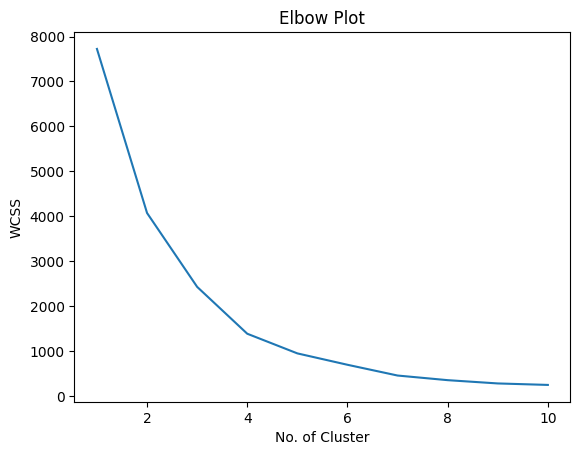

In [27]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=0)
    kmeans.fit(X_blb_sc)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')
plt.show()

In [28]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans_blb = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=0)
y_blb_kmeans = kmeans_blb.fit_predict(X_blb_sc)

In [29]:
print(y_blb_kmeans)

[0 2 1 ... 2 2 0]


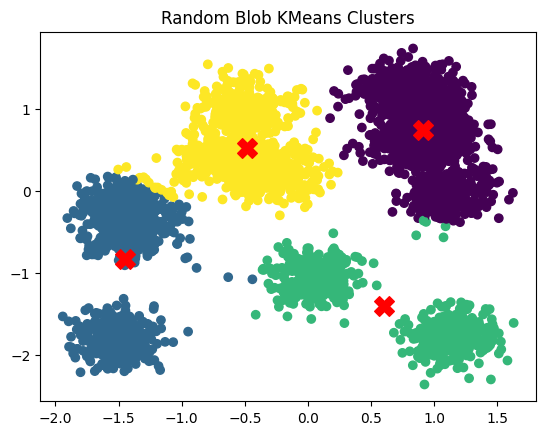

In [30]:
# Plot the clusters
plt.scatter(X_blb_sc[:,0], X_blb_sc[:,1], c=y_blb_kmeans)
plt.scatter(kmeans_blb.cluster_centers_[:,0], kmeans_blb.cluster_centers_[:,1], s=200, c='red', marker='X')
plt.title('Random Blob KMeans Clusters')
plt.show()